In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Chargement du dataset généré au Livrable 2
df_clus = pd.read_csv('../data/olist_engineered_clustering.csv')
features = ['recency', 'frequency', 'monetary_value', 'mean_freight']

# Standardisation (indispensable pour K-Means, DBSCAN et CAH)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clus[features])

print(f"Données prêtes pour le Clustering : {X_scaled.shape[0]} clients uniques.")

Données prêtes pour le Clustering : 93358 clients uniques.


C:\Users\maell\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\maell\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Program Files\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python311\Lib\subprocess.py", line 1538, in _execute_child
  

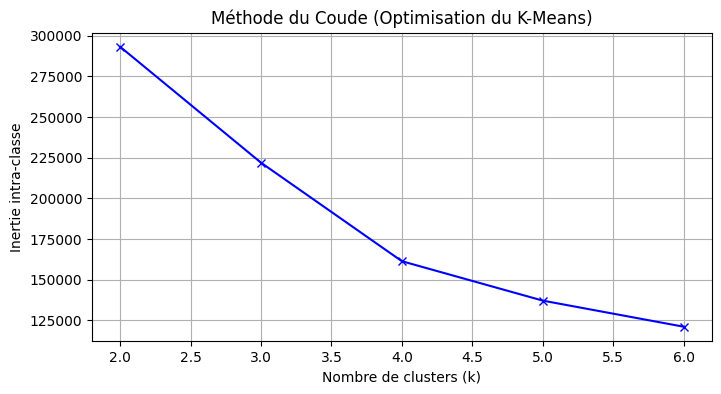

K-Means entraîné avec 4 clusters.


,recency,frequency,monetary_value,mean_freight
cluster_kmeans,,,,
0,388.808169,1.000000,131.786816,17.615410
1,214.713487,1.003261,774.749182,66.991882
2,129.146268,1.000000,129.586375,18.118689
3,220.106925,2.114460,298.712243,18.661150


In [6]:
from sklearn.cluster import KMeans

# 1. Recherche du k optimal (Méthode du coude)
inertia = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# 2. Affichage du graphique
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie intra-classe')
plt.title('Méthode du Coude (Optimisation du K-Means)')
plt.grid(True)
plt.show()

# 3. Application du modèle final (Ajuste n_clusters selon ton graphique, souvent 4 ou 5)
best_k = 4 
kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_clus['cluster_kmeans'] = kmeans_model.fit_predict(X_scaled)

print(f"K-Means entraîné avec {best_k} clusters.")
# Affichage des profils pour ton PDF
df_clus.groupby('cluster_kmeans')[features].mean()

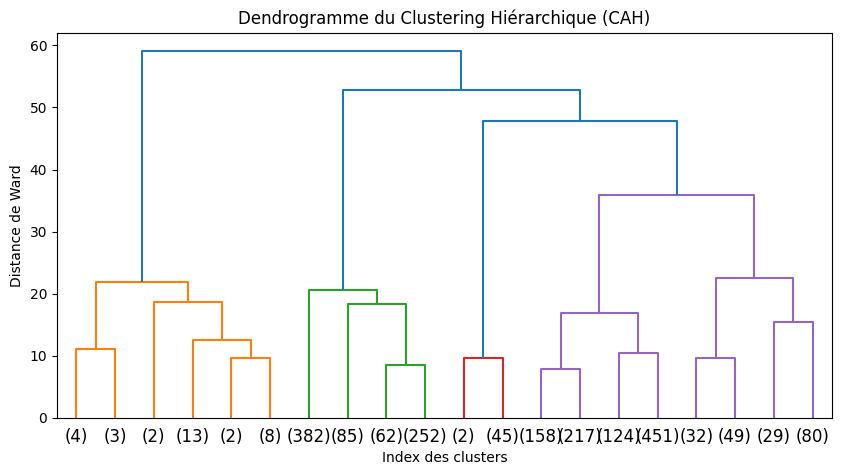

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Échantillonnage pour éviter que le PC ne plante (le CAH calcule toutes les distances 2 à 2)
X_sample = X_scaled[:2000] 

# Calcul des liens selon la méthode de Ward
Z = linkage(X_sample, method='ward')

# Affichage du Dendrogramme pour ton PDF
plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title('Dendrogramme du Clustering Hiérarchique (CAH)')
plt.xlabel('Index des clusters')
plt.ylabel('Distance de Ward')
plt.show()